## Step 1 - Data Inspection & Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('test.csv')
df

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,52685,36,Male,13,Healthcare,8029,Excellent,High,Average,1,...,1,Mid,Large,22,No,No,No,Poor,Medium,Stayed
1,30585,35,Male,7,Education,4563,Good,High,Average,1,...,4,Entry,Medium,27,No,No,No,Good,High,Left
2,54656,50,Male,7,Education,5583,Fair,High,Average,3,...,2,Senior,Medium,76,No,No,Yes,Good,Low,Stayed
3,33442,58,Male,44,Media,5525,Fair,Very High,High,0,...,4,Entry,Medium,96,No,No,No,Poor,Low,Left
4,15667,39,Male,24,Education,4604,Good,High,Average,0,...,6,Mid,Large,45,Yes,No,No,Good,High,Stayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14895,16243,56,Female,42,Healthcare,7830,Poor,Medium,Average,0,...,0,Senior,Medium,60,No,No,No,Poor,Medium,Stayed
14896,47175,30,Female,15,Education,3856,Good,Medium,Average,2,...,0,Entry,Medium,20,No,No,No,Good,Medium,Left
14897,12409,52,Male,5,Education,5654,Good,Very High,Below Average,0,...,4,Mid,Small,7,No,No,No,Good,High,Left
14898,9554,18,Male,4,Education,5276,Fair,High,Average,0,...,3,Mid,Large,5,No,No,No,Poor,High,Stayed


In [3]:
df.shape

(14900, 24)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14900 entries, 0 to 14899
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               14900 non-null  int64 
 1   Age                       14900 non-null  int64 
 2   Gender                    14900 non-null  object
 3   Years at Company          14900 non-null  int64 
 4   Job Role                  14900 non-null  object
 5   Monthly Income            14900 non-null  int64 
 6   Work-Life Balance         14900 non-null  object
 7   Job Satisfaction          14900 non-null  object
 8   Performance Rating        14900 non-null  object
 9   Number of Promotions      14900 non-null  int64 
 10  Overtime                  14900 non-null  object
 11  Distance from Home        14900 non-null  int64 
 12  Education Level           14900 non-null  object
 13  Marital Status            14900 non-null  object
 14  Number of Dependents  

In [5]:
df = df.drop('Employee ID', axis=1)

## Step 2 - Visualization & Insights (MANDATORY) 

In [6]:
df.describe()

,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
count,14900.000000,14900.000000,14900.000000,14900.000000,14900.000000,14900.000000,14900.000000
mean,38.385235,15.592416,7287.306040,0.834362,49.927315,1.659329,55.603624
std,12.097904,11.133792,2156.737934,0.996511,28.702307,1.545401,25.352807
min,18.000000,1.000000,1226.000000,0.000000,1.000000,0.000000,2.000000
25%,28.000000,7.000000,5633.750000,0.000000,25.000000,0.000000,36.000000
50%,38.000000,13.000000,7332.000000,1.000000,50.000000,1.000000,56.000000
75%,49.000000,23.000000,8852.000000,2.000000,75.000000,3.000000,75.000000
max,59.000000,51.000000,15063.000000,4.000000,99.000000,6.000000,127.000000


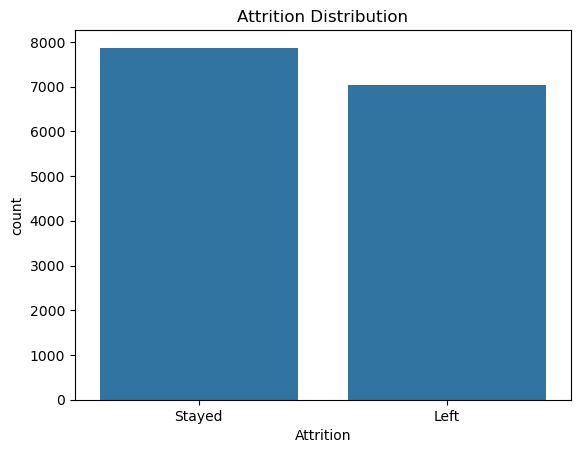

In [7]:
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Distribution')
plt.show()

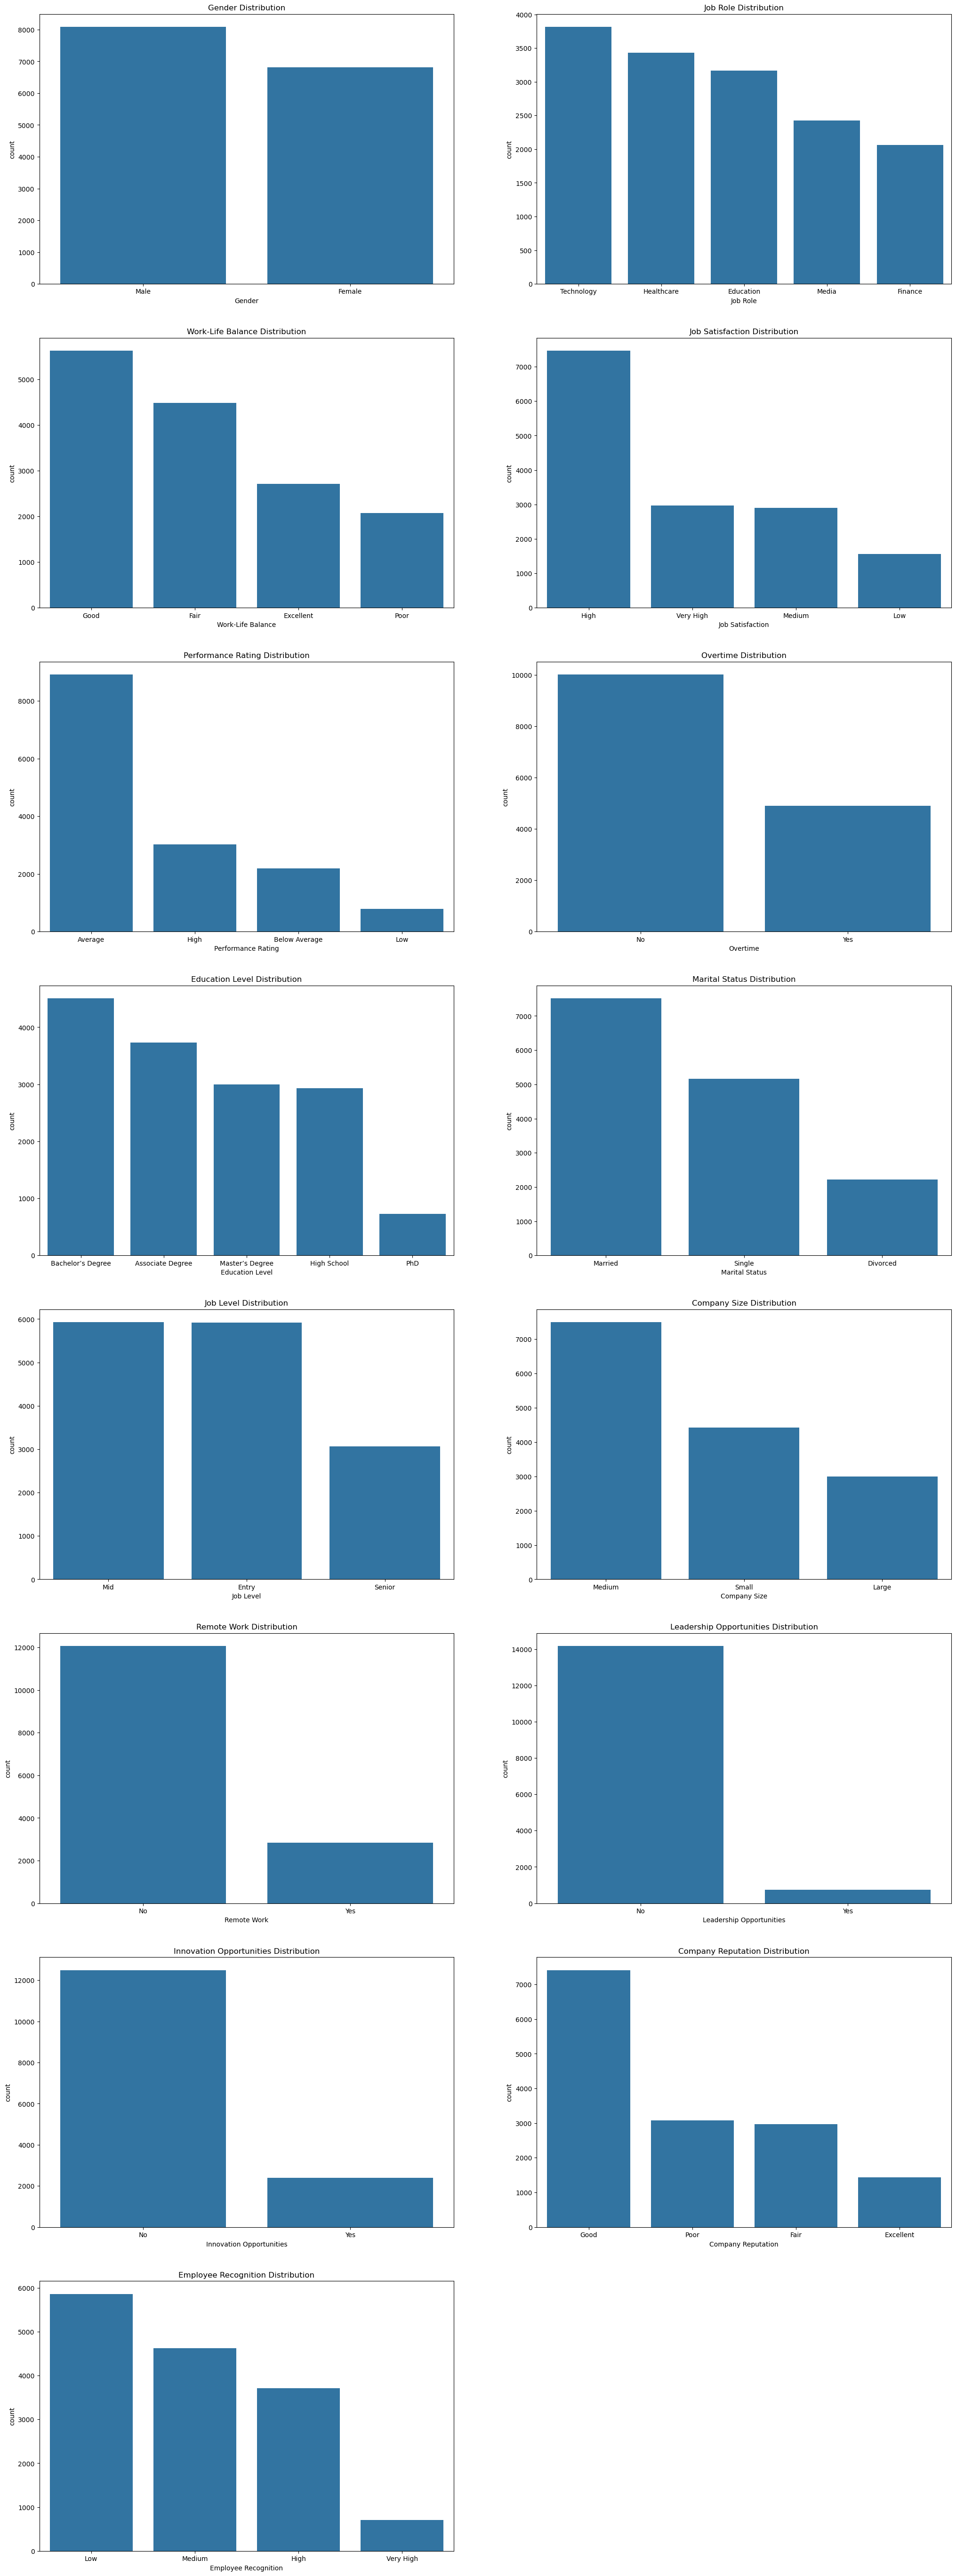

In [8]:
plt.figure(figsize = (25,70))
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = cat_cols.drop('Attrition')
for i, col in enumerate(cat_cols):
    plt.subplot(8,2,i+1)
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f'{col} Distribution')
plt.show()

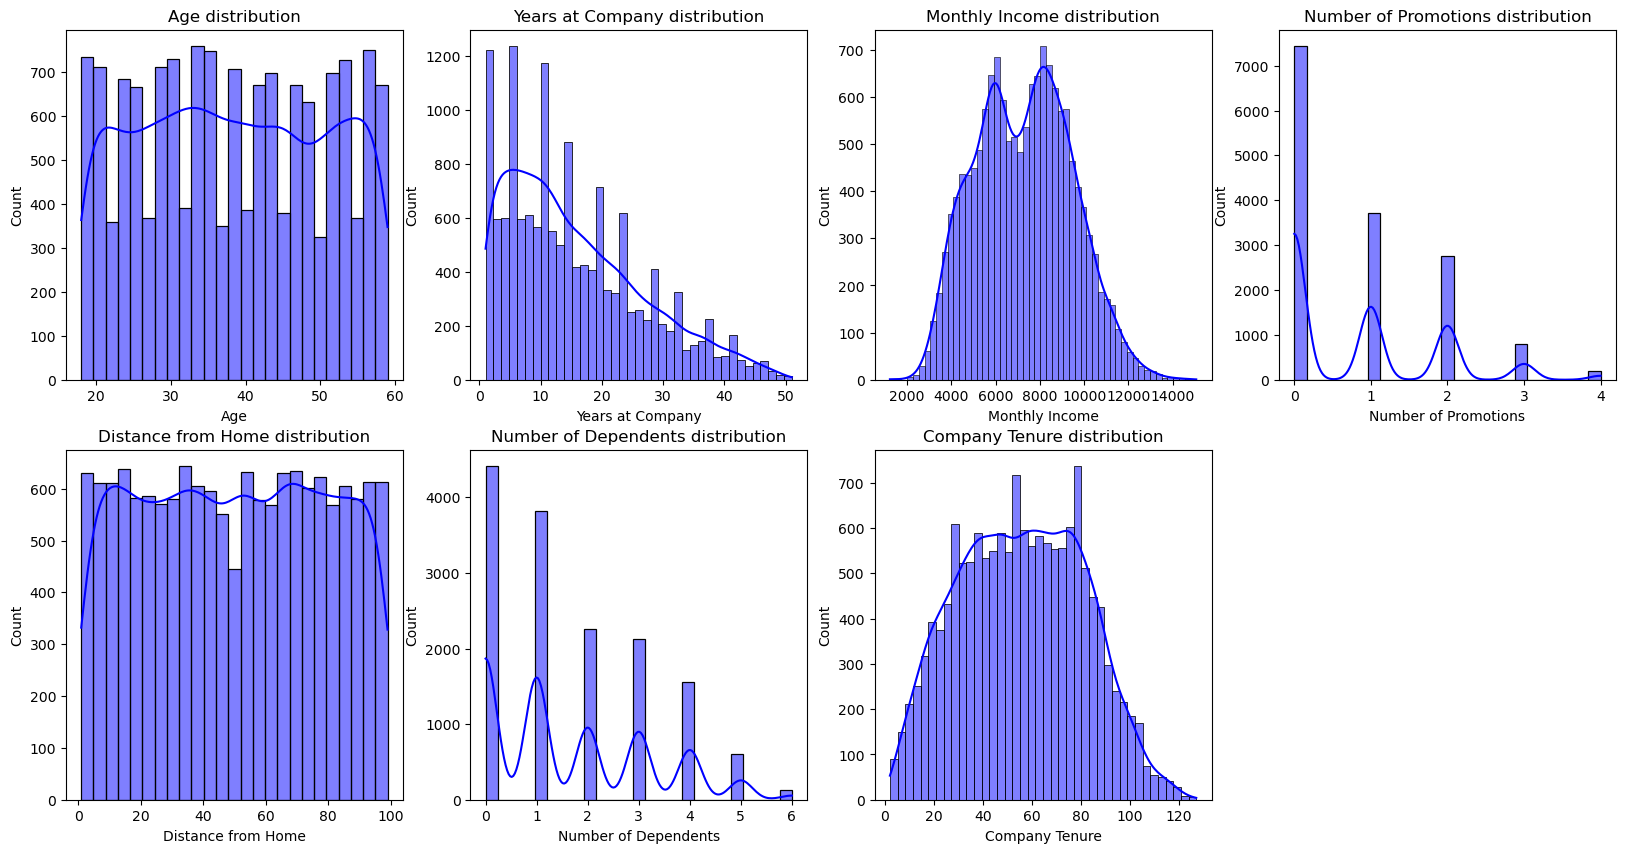

In [9]:
plt.figure(figsize = (20,10))
cont_cols = df.select_dtypes(include=['int64']).columns
for i, col in enumerate(cont_cols):
    plt.subplot(2,4,i+1)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'{col} distribution')
plt.show()

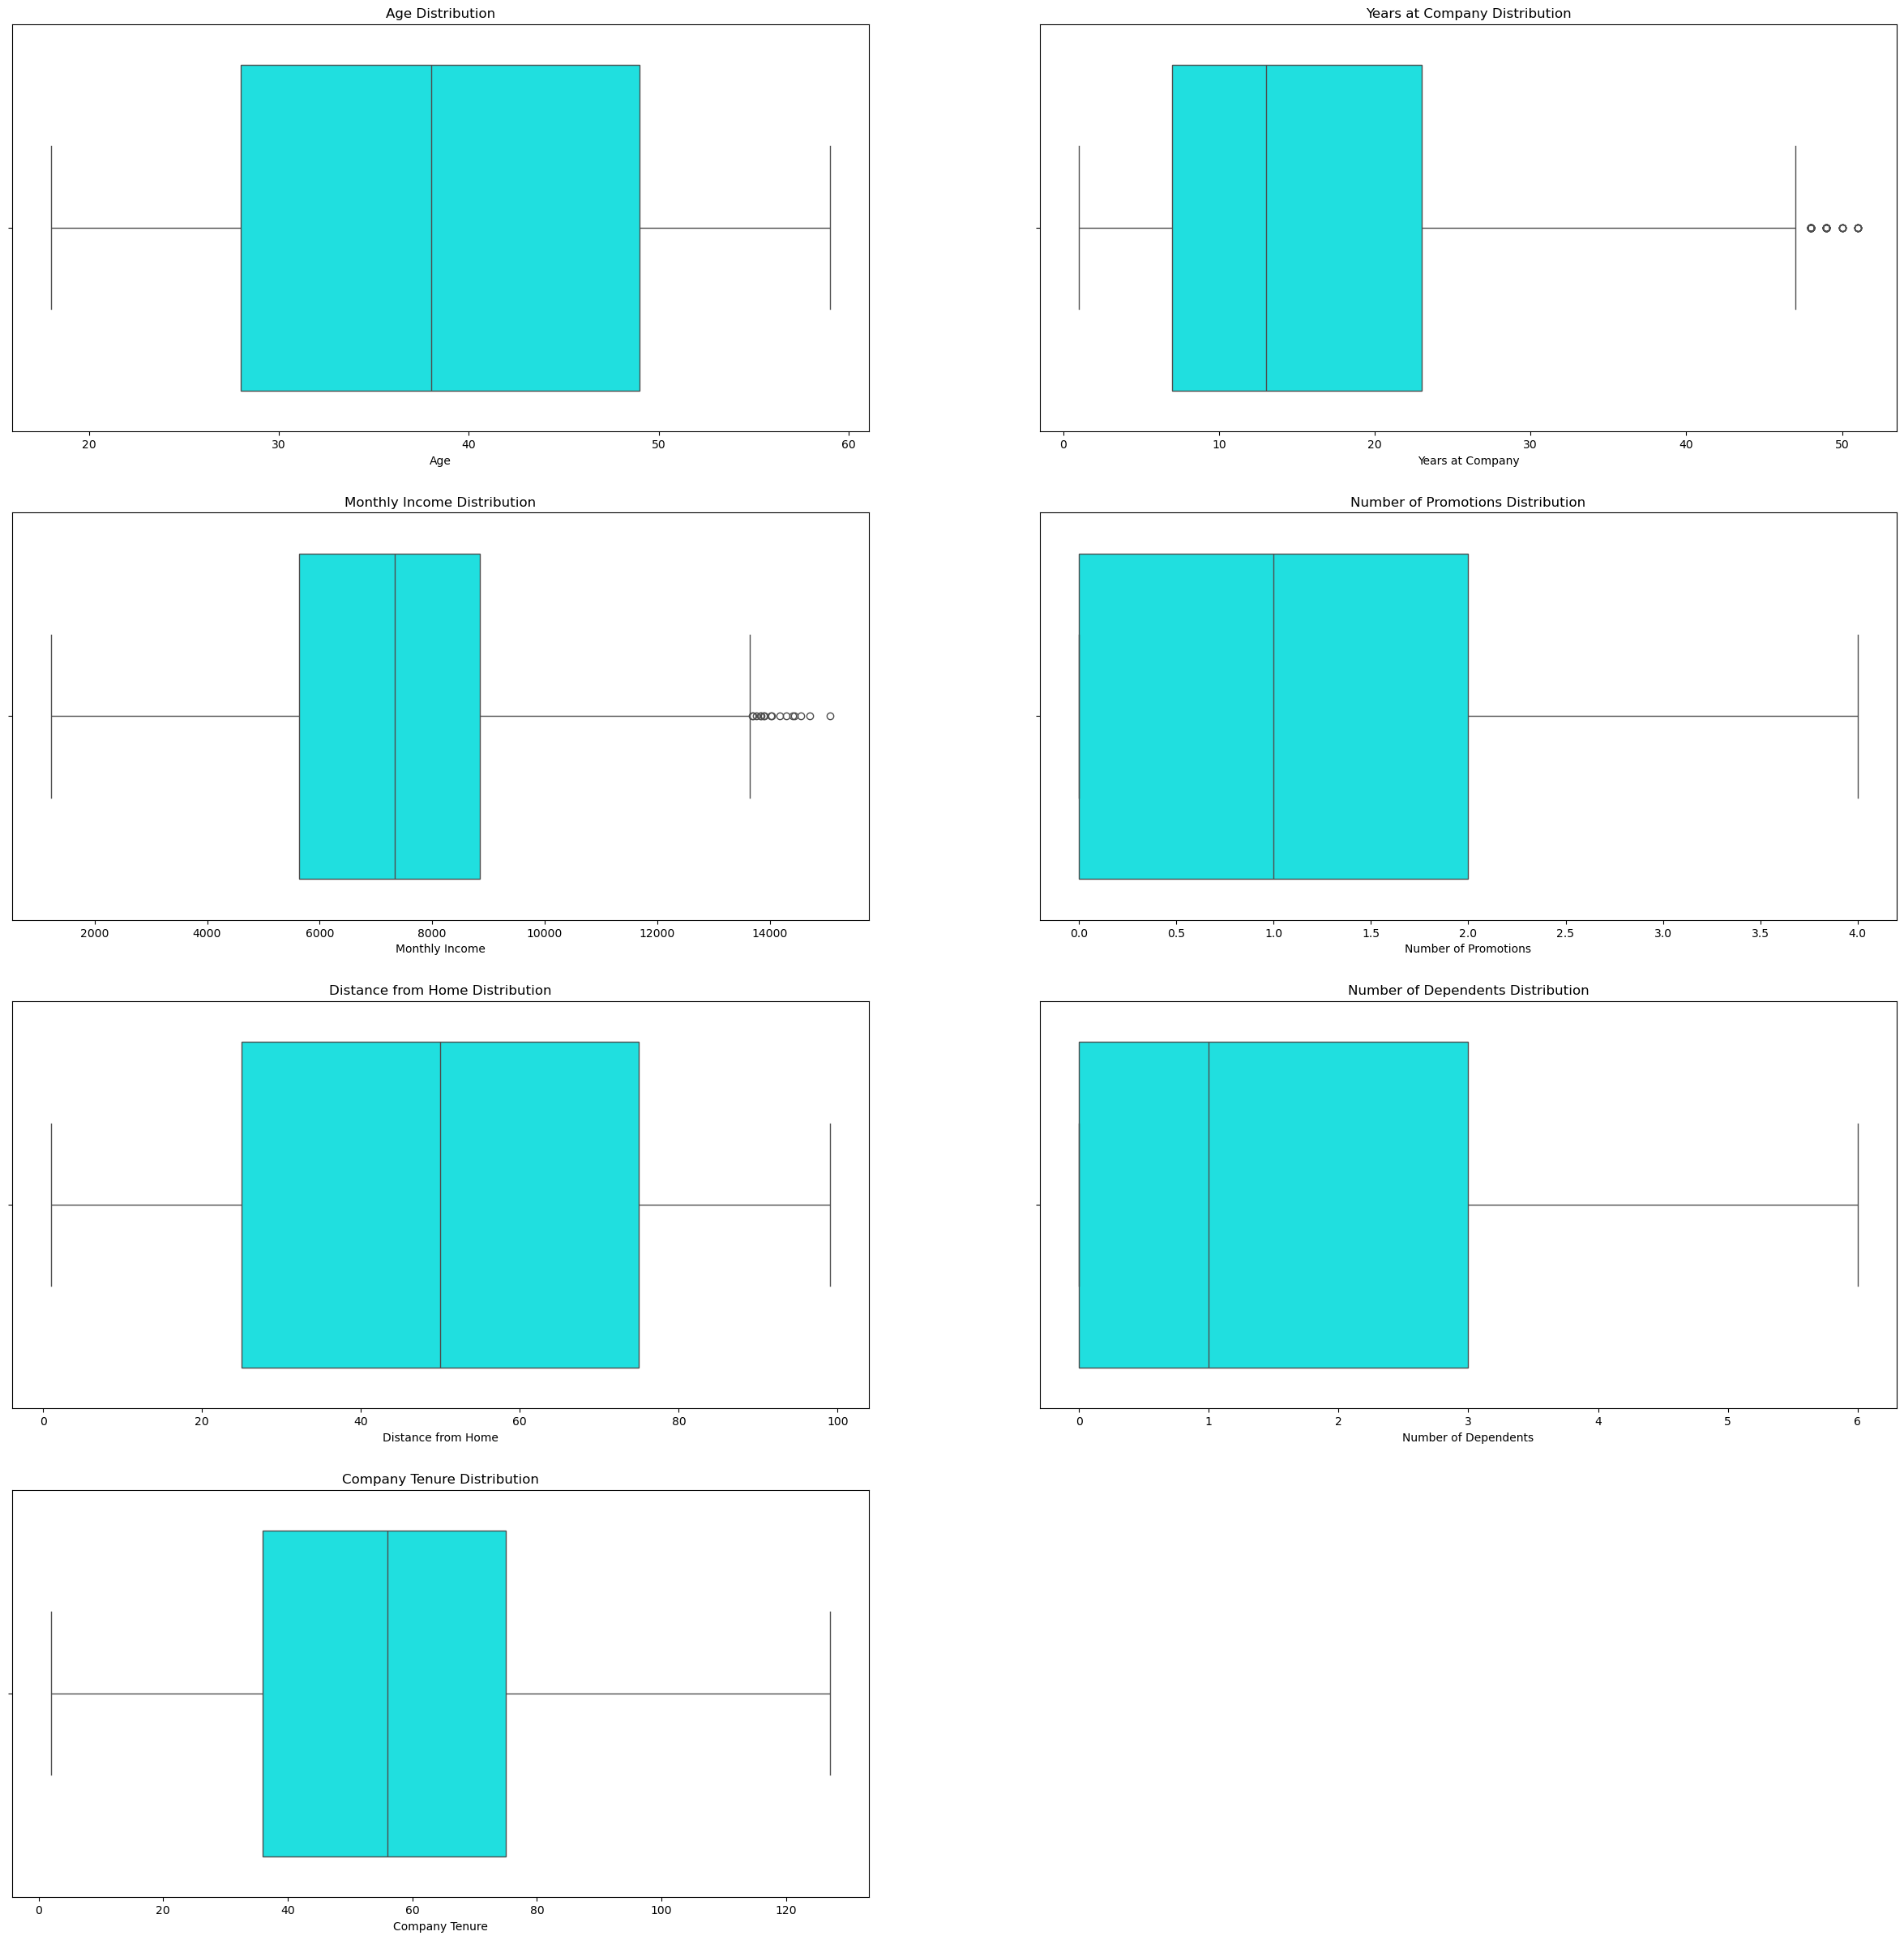

In [10]:
plt.figure(figsize = (30,30))
for i, col in enumerate(cont_cols):
    plt.subplot(4,2,i+1)
    sns.boxplot(x=df[col],color = 'cyan')
    plt.title(f'{col} Distribution')
plt.show()

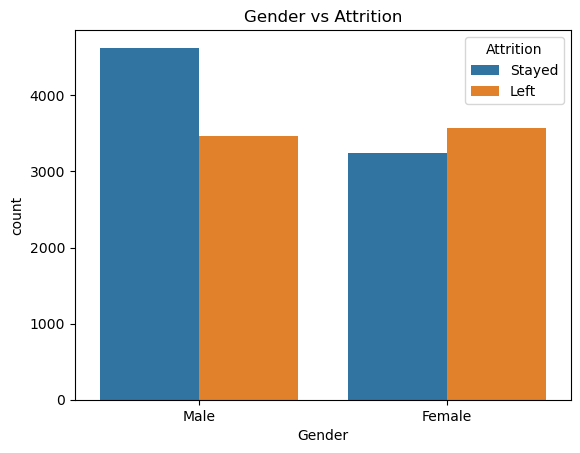

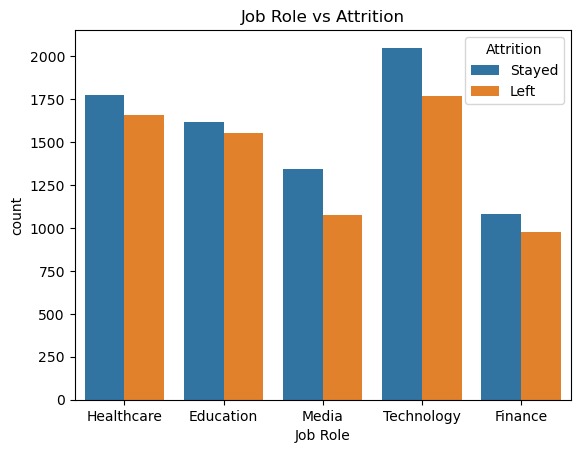

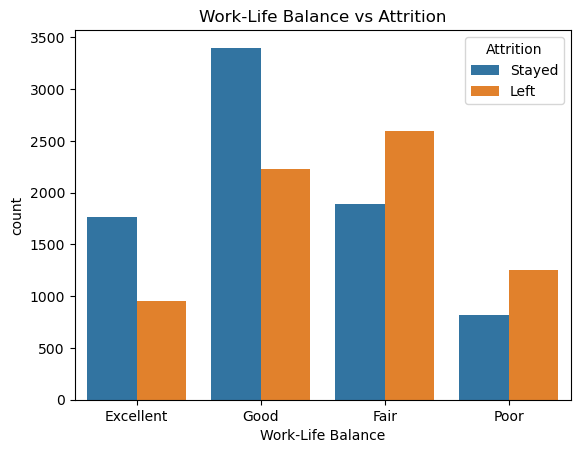

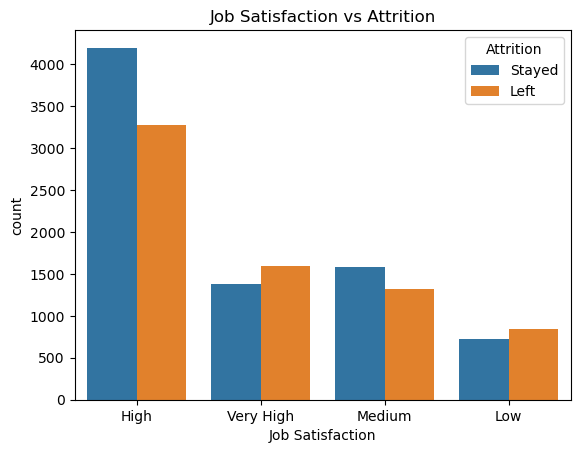

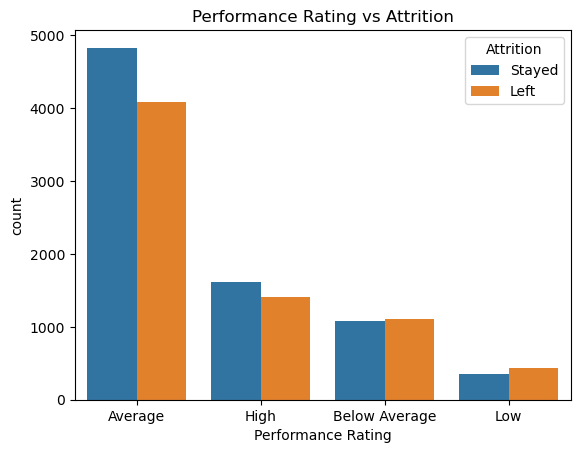

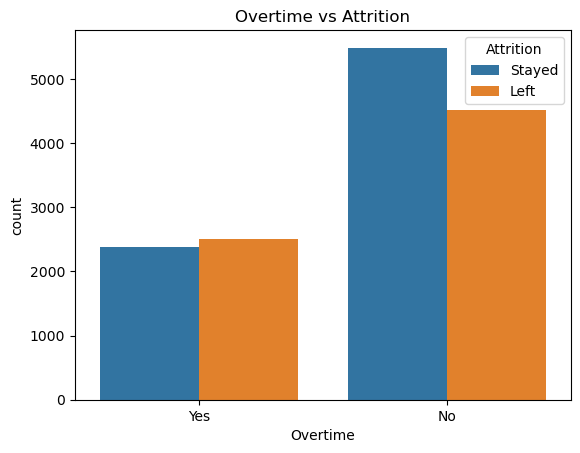

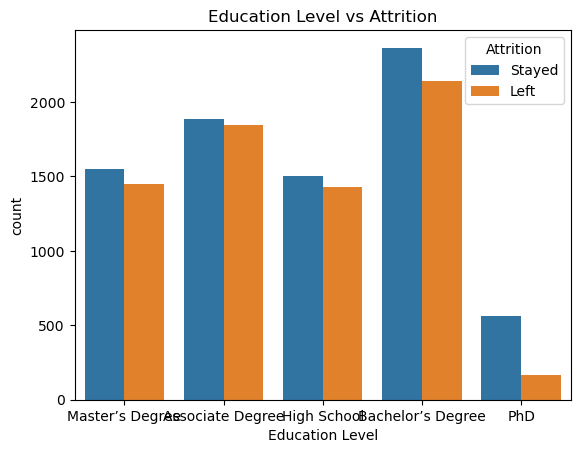

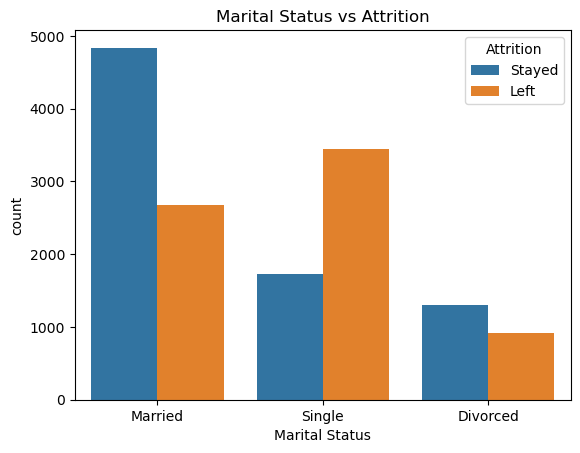

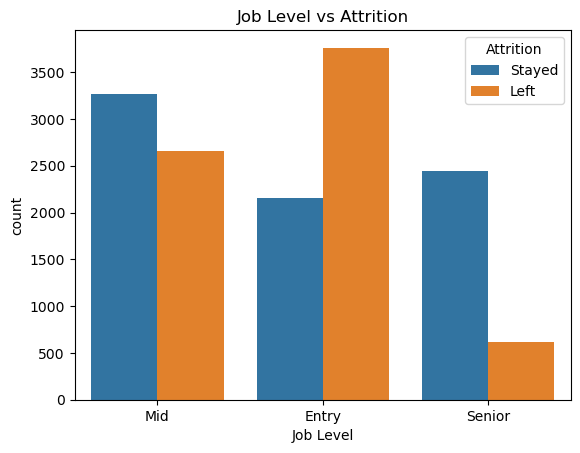

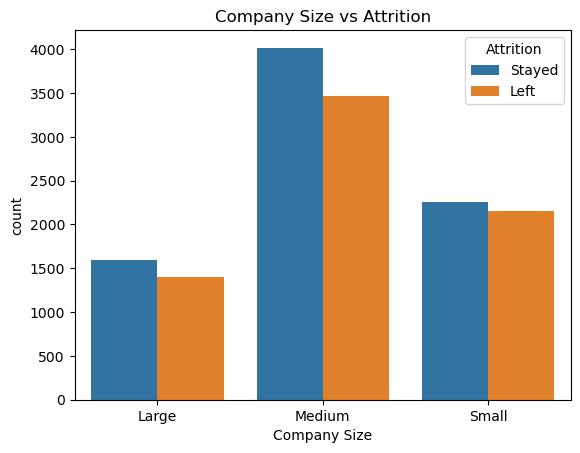

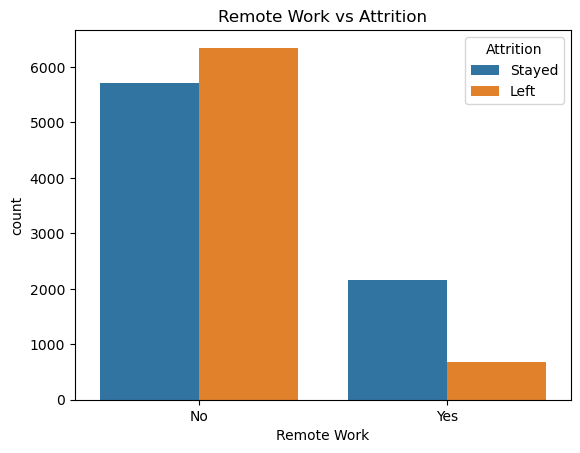

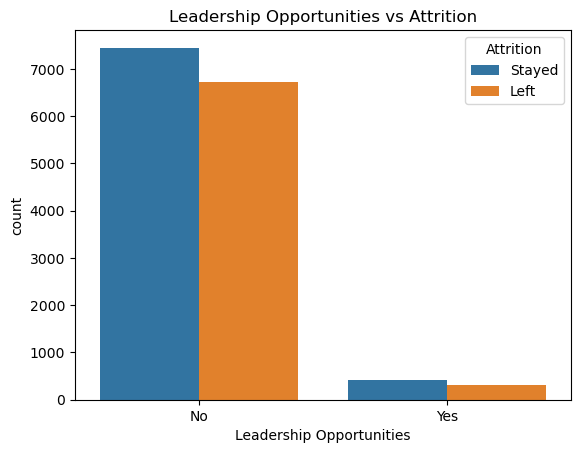

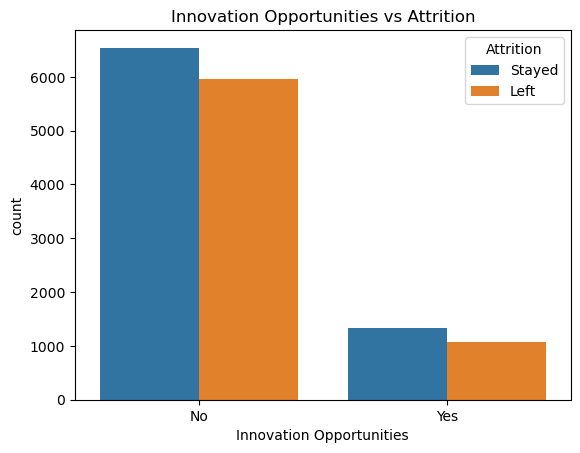

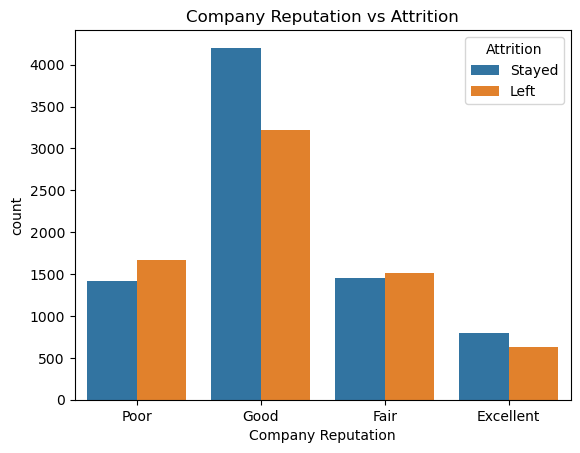

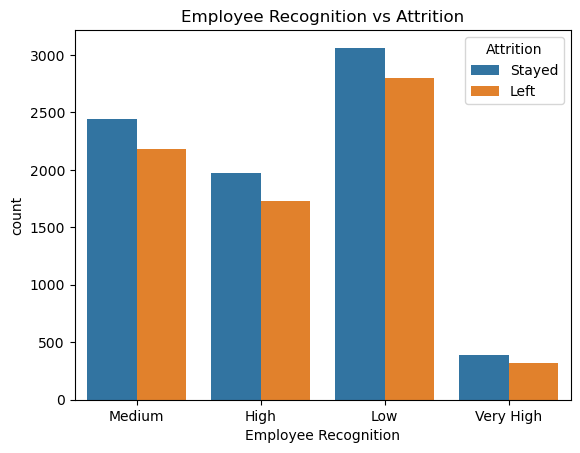

In [11]:
for col in cat_cols:
    sns.countplot(x=col, data=df, hue='Attrition')
    plt.title(f'{col} vs Attrition')
    plt.show()

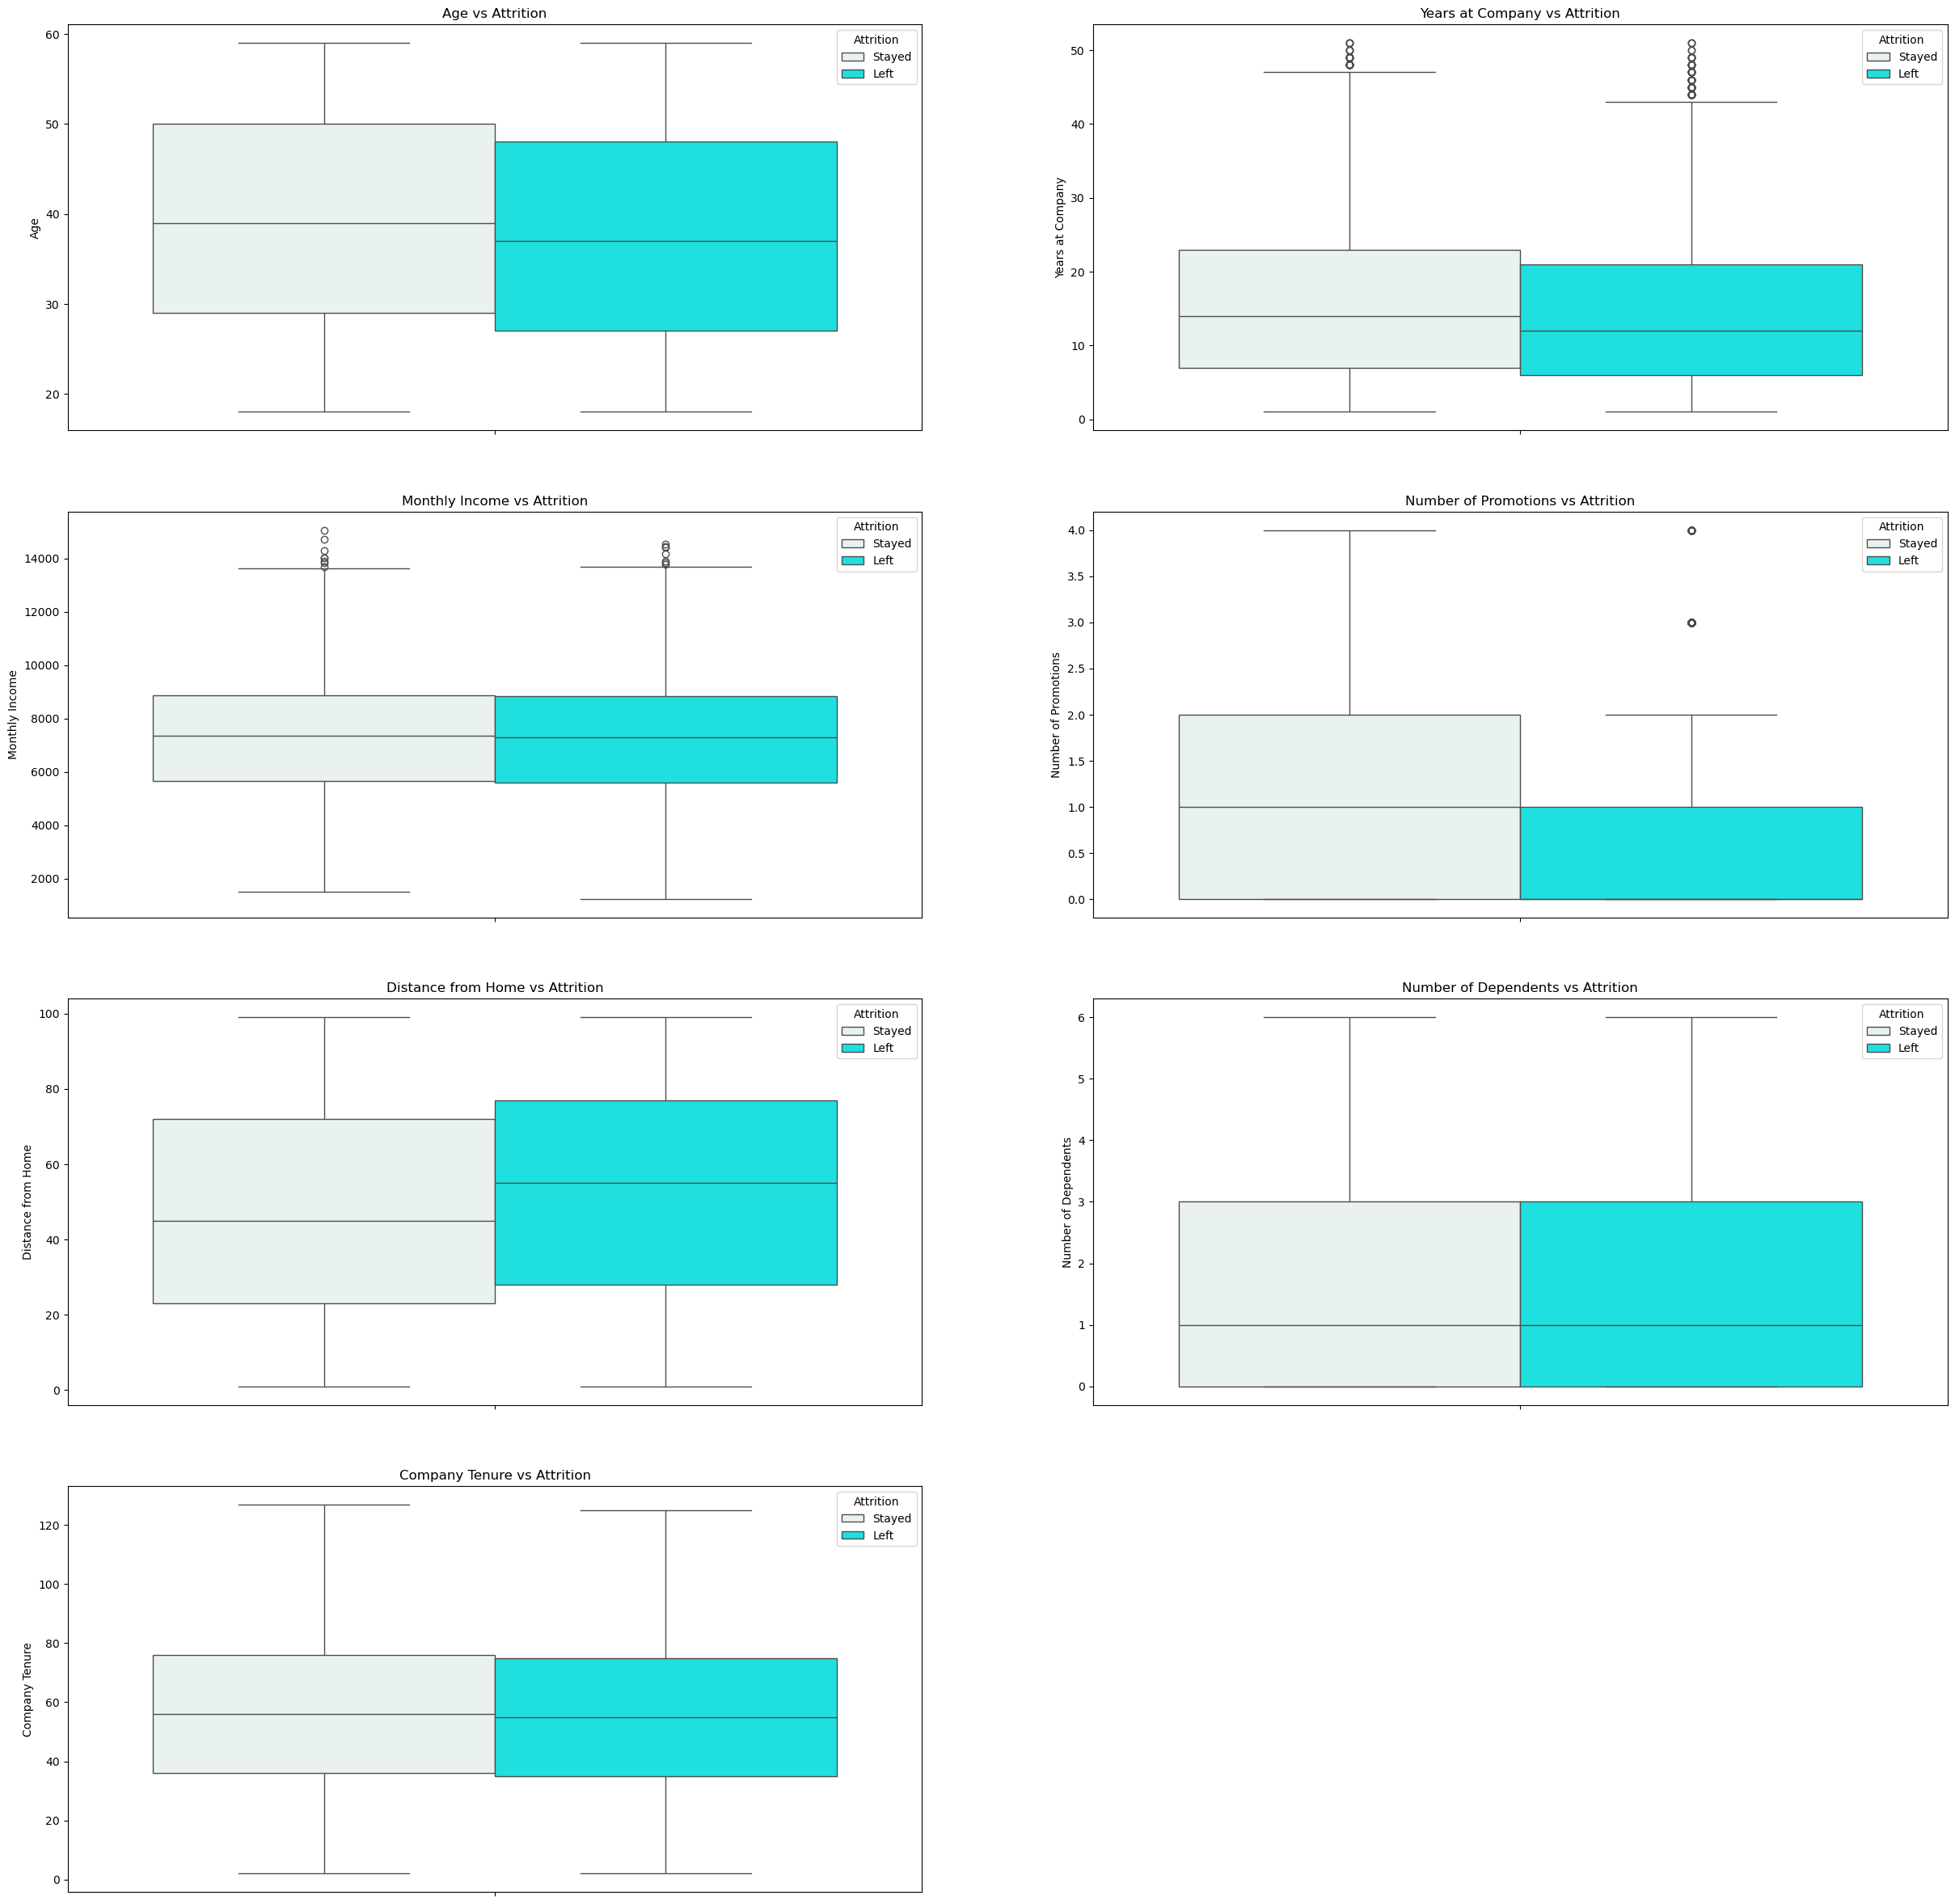

In [12]:
plt.figure(figsize = (30,30))
for i, col in enumerate(cont_cols):
    plt.subplot(4,2,i+1)
    sns.boxplot(y=col, hue = 'Attrition', color = 'cyan', data=df, palette='light:cyan')
    plt.title(f'{col} vs Attrition')
plt.show()

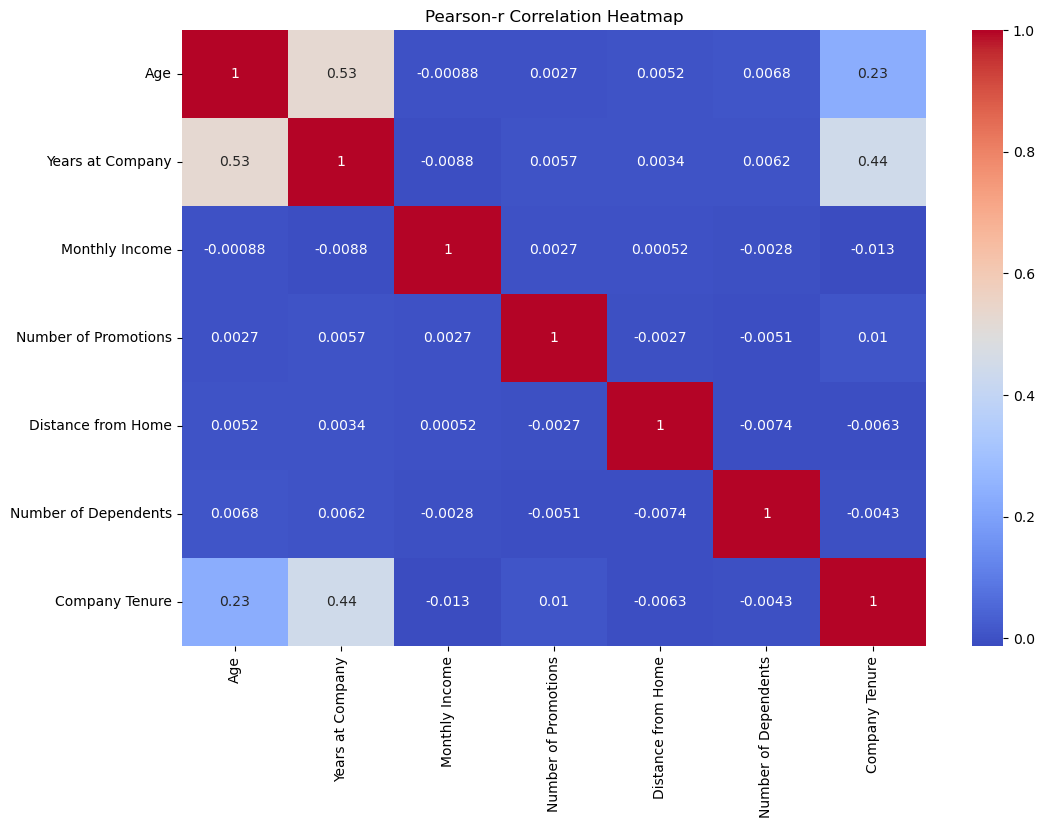

In [13]:
# Pearson-r Correlation Matrix
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Pearson-r Correlation Heatmap')
plt.show()

* Numerical: `Age`, `Years at Company`, `Monthly Income`, `Distance from Home`, `Company Tenure`
* Nominal Category: `Number of Promotions`, `Number of Dependents`, `Job Role`, `Marital Status`
* Ordinal Category: `Work-Life Balance`, `Job Satisfaction`, `Performance Rating`, `Education Level`, `Job Level`, `Company Size`
  , `Company Reputation`, `Employee Recognition`
* Binary Category: `Gender`, `Overtime`, `Remote Work`, `Leadership Opportunities`, `Innovation Opportunities`
* Target: `Attrition`

## Step 3 - Preprocessing & Encoding Decisions 

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
for col in ['Years at Company', 'Monthly Income']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[~((df[col] < lower_bound) | (df[col] > upper_bound))]

In [16]:
for col in df.columns[df.dtypes == 'object']:
    print(f'{col}: {df[col].unique()}')

Gender: ['Male' 'Female']
Job Role: ['Healthcare' 'Education' 'Media' 'Technology' 'Finance']
Work-Life Balance: ['Excellent' 'Good' 'Fair' 'Poor']
Job Satisfaction: ['High' 'Very High' 'Medium' 'Low']
Performance Rating: ['Average' 'High' 'Below Average' 'Low']
Overtime: ['Yes' 'No']
Education Level: ['Master’s Degree' 'Associate Degree' 'High School' 'Bachelor’s Degree'
 'PhD']
Marital Status: ['Married' 'Single' 'Divorced']
Job Level: ['Mid' 'Entry' 'Senior']
Company Size: ['Large' 'Medium' 'Small']
Remote Work: ['No' 'Yes']
Leadership Opportunities: ['No' 'Yes']
Innovation Opportunities: ['No' 'Yes']
Company Reputation: ['Poor' 'Good' 'Fair' 'Excellent']
Employee Recognition: ['Medium' 'High' 'Low' 'Very High']
Attrition: ['Stayed' 'Left']


In [17]:
from sklearn.preprocessing import OneHotEncoder

In [18]:
#Binary encoding
yesNo = {'Yes': 1, 'No': 0}
for col in ['Overtime', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities']:
    df[col] = df[col].map(yesNo)

gender = {'Male' : 1, 'Female' : 0}
df['Gender'] = df['Gender'].map(gender)

attrition = {'Stayed' : 0, 'Left' : 1}
df['Attrition'] = df['Attrition'].map(attrition)

#Ordinal encoding
#`Work-Life Balance`, `Job Satisfaction`, `Performance Rating`, `Education Level`, `Job Level`, `Company Size`, `Company Reputation`, `Employee Recognition`
workLife = {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4}
df['Work-Life Balance'] = df['Work-Life Balance'].map(workLife)

jobSatisfaction = {'High': 3,'Very High': 4,'Medium': 2,'Low':1}
df['Job Satisfaction'] = df['Job Satisfaction'].map(jobSatisfaction)

perf_rating = {'Average': 3, 'High': 4, 'Below Average': 2, 'Low': 1}
df['Performance Rating'] = df['Performance Rating'].map(perf_rating)

education_order = {'High School': 1, 'Associate Degree': 2, 'Bachelor’s Degree': 3, 'Master’s Degree': 4, 'PhD': 5}
df['Education Level'] = df['Education Level'].map(education_order)

job_level_order = {'Entry': 1, 'Mid': 2, 'Senior': 3}
df['Job Level'] = df['Job Level'].map(job_level_order)

company_size_order = {'Small': 1, 'Medium': 2, 'Large': 3}
df['Company Size'] = df['Company Size'].map(company_size_order)

reputation_order = {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4}
df['Company Reputation'] = df['Company Reputation'].map(reputation_order)

recognition_order = {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
df['Employee Recognition'] = df['Employee Recognition'].map(recognition_order)

#Nominal encoding
df = df.drop_duplicates().reset_index(drop=True)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(df[['Job Role', 'Marital Status']])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['Job Role', 'Marital Status']))
df = pd.concat([df.drop(['Job Role', 'Marital Status'], axis=1), encoded_df], axis=1)

In [19]:
df

,Age,Gender,Years at Company,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,...,Employee Recognition,Attrition,Job Role_Education,Job Role_Finance,Job Role_Healthcare,Job Role_Media,Job Role_Technology,Marital Status_Divorced,Marital Status_Married,Marital Status_Single
0,36,1,13,8029,4,3,3,1,1,83,...,2,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,35,1,7,4563,3,3,3,1,1,55,...,3,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,50,1,7,5583,2,3,3,3,1,14,...,1,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,58,1,44,5525,2,4,4,0,1,43,...,1,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,39,1,24,4604,3,3,3,0,1,47,...,3,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14814,52,1,13,9296,1,3,3,1,1,31,...,1,0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
14815,56,0,42,7830,1,2,3,0,1,40,...,2,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
14816,30,0,15,3856,3,2,3,2,1,45,...,2,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
14817,52,1,5,5654,3,4,2,0,0,4,...,3,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14819 entries, 0 to 14818
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       14819 non-null  int64  
 1   Gender                    14819 non-null  int64  
 2   Years at Company          14819 non-null  int64  
 3   Monthly Income            14819 non-null  int64  
 4   Work-Life Balance         14819 non-null  int64  
 5   Job Satisfaction          14819 non-null  int64  
 6   Performance Rating        14819 non-null  int64  
 7   Number of Promotions      14819 non-null  int64  
 8   Overtime                  14819 non-null  int64  
 9   Distance from Home        14819 non-null  int64  
 10  Education Level           14819 non-null  int64  
 11  Number of Dependents      14819 non-null  int64  
 12  Job Level                 14819 non-null  int64  
 13  Company Size              14819 non-null  int64  
 14  Compan

## Step 4 — Insights & Feature Selection¶

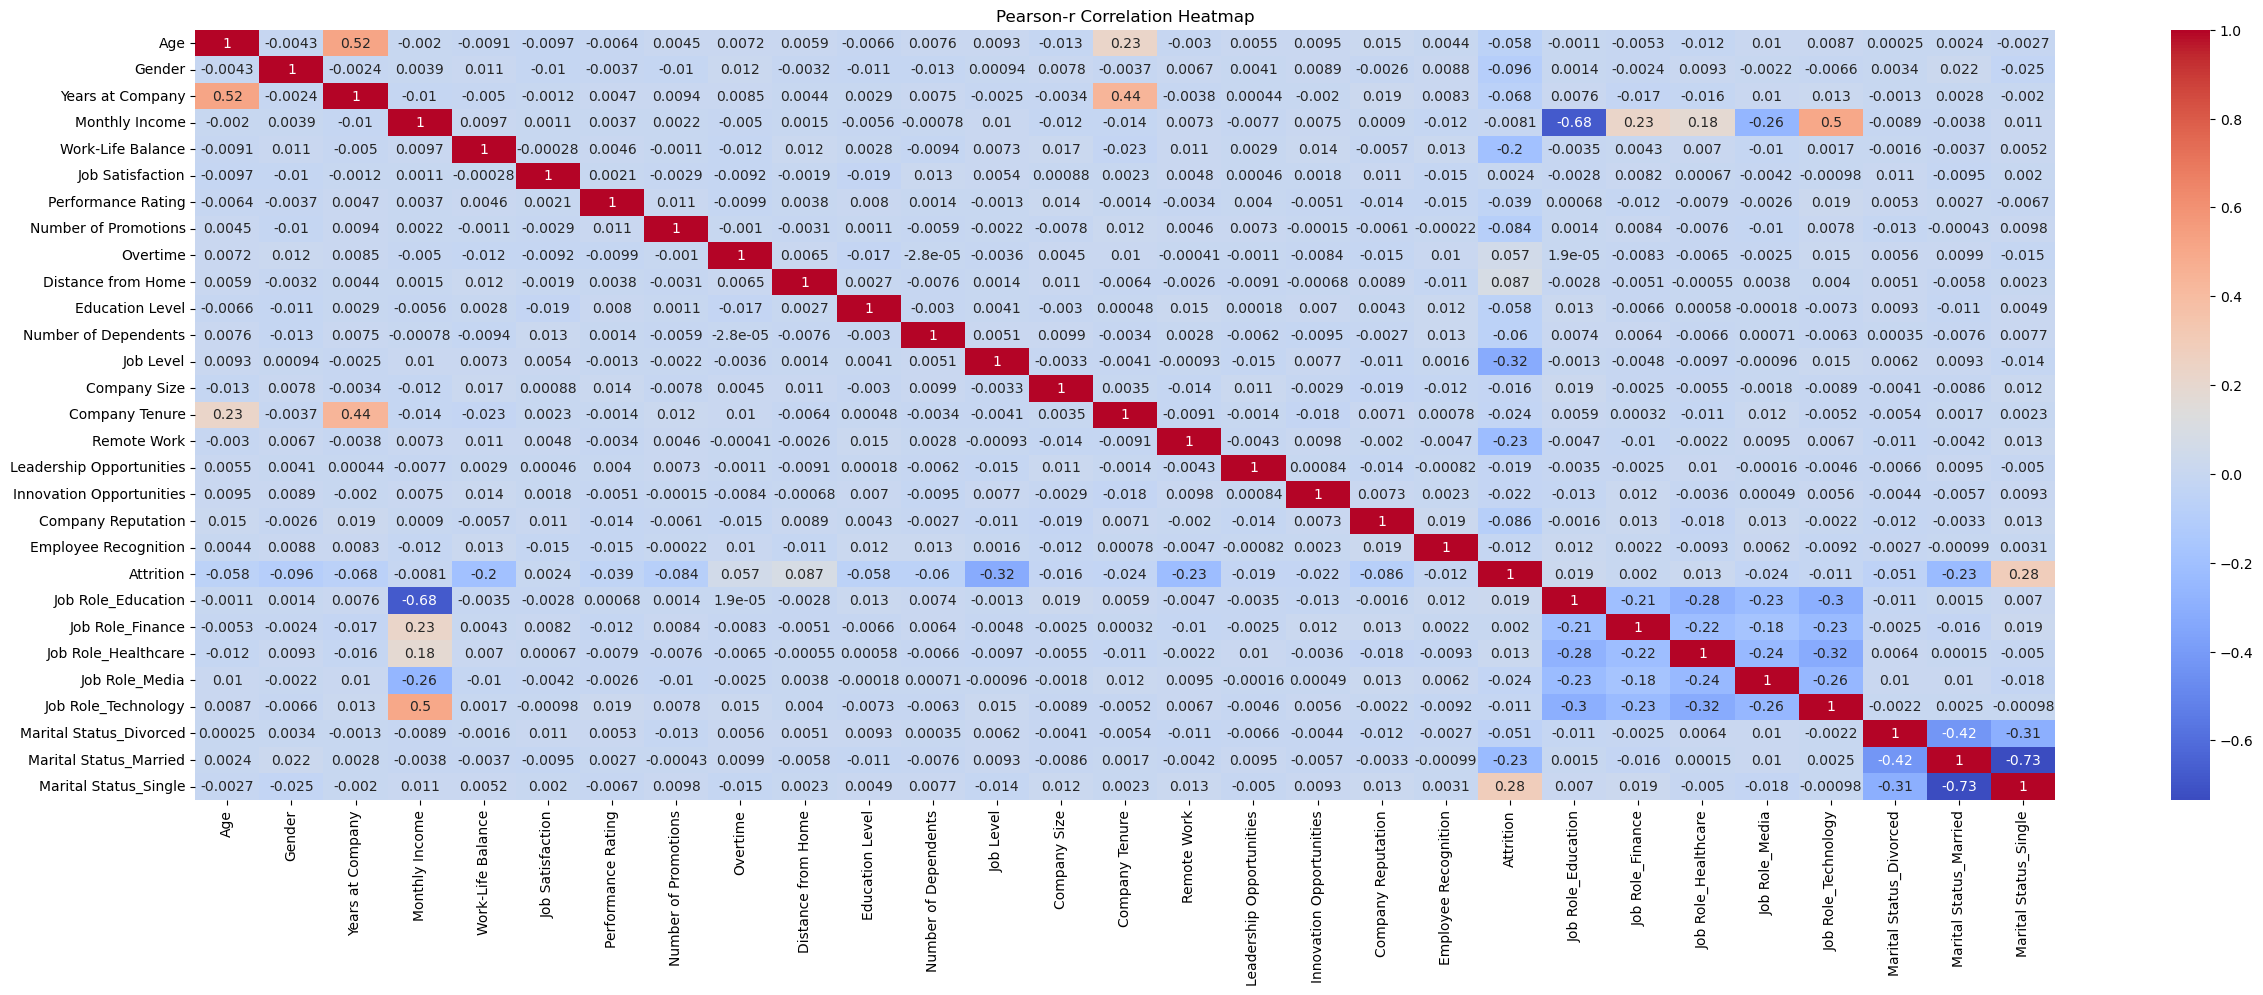

In [21]:
# Pearson-r Correlation Matrix
plt.figure(figsize=(30, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Pearson-r Correlation Heatmap')
plt.show()

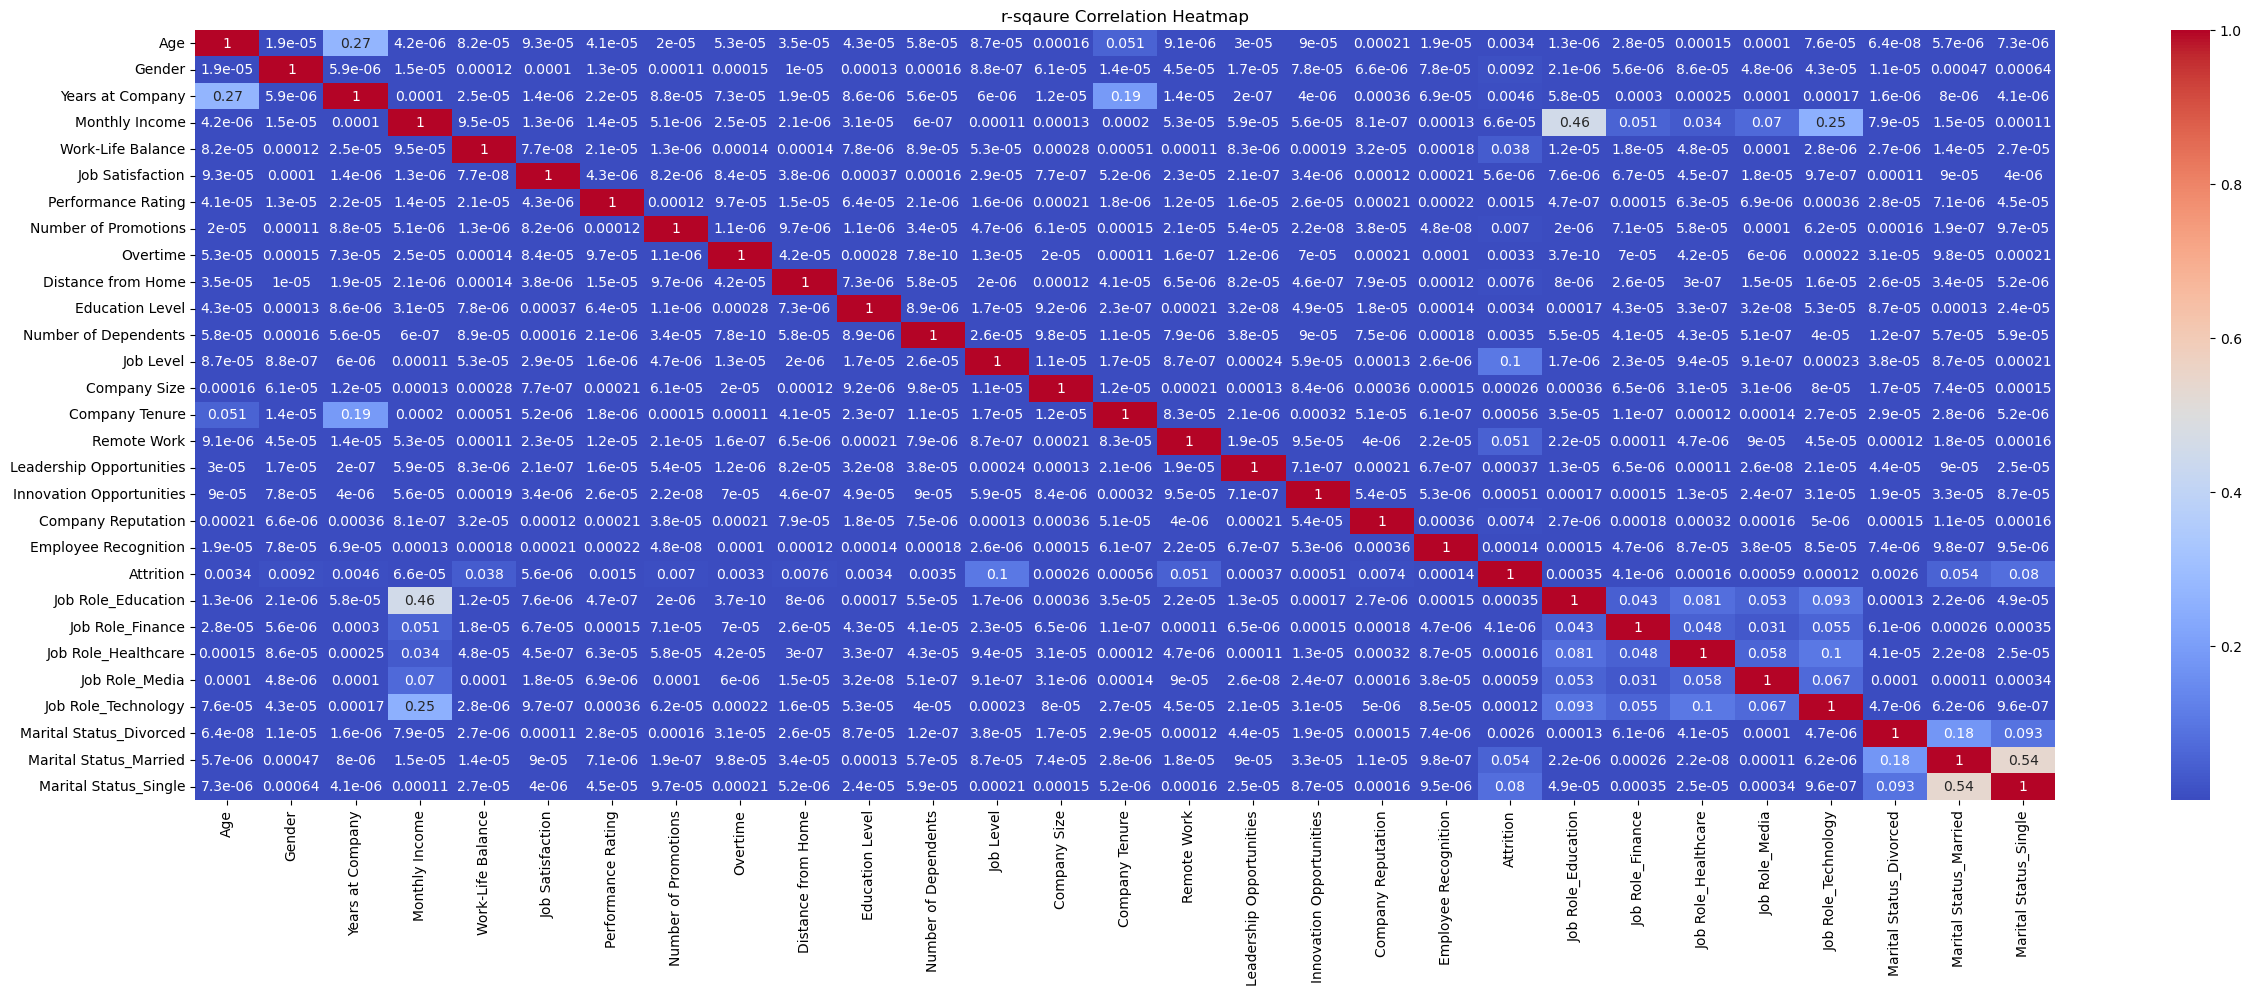

In [22]:
# r-sqaured Correlation Matrix
plt.figure(figsize=(30, 10))
r_square = (df.corr(numeric_only=True)) ** 2
sns.heatmap(r_square, annot=True, cmap='coolwarm')
plt.title('r-sqaure Correlation Heatmap')
plt.show()

In [23]:
impact_results = r_square['Attrition'].drop('Attrition', axis = 0).sort_values(ascending=False)
print(impact_results)

Job Level                   0.103683
Marital Status_Single       0.080058
Marital Status_Married      0.054394
Remote Work                 0.050694
Work-Life Balance           0.038333
Gender                      0.009232
Distance from Home          0.007577
Company Reputation          0.007370
Number of Promotions        0.007005
Years at Company            0.004569
Number of Dependents        0.003543
Age                         0.003408
Education Level             0.003381
Overtime                    0.003288
Marital Status_Divorced     0.002555
Performance Rating          0.001487
Job Role_Media              0.000593
Company Tenure              0.000556
Innovation Opportunities    0.000505
Leadership Opportunities    0.000366
Job Role_Education          0.000355
Company Size                0.000259
Job Role_Healthcare         0.000160
Employee Recognition        0.000138
Job Role_Technology         0.000118
Monthly Income              0.000066
Job Satisfaction            0.000006
J

In [24]:
print("Top Impactful Features identified:")
print(impact_results.head(3))

Top Impactful Features identified:
Job Level                 0.103683
Marital Status_Single     0.080058
Marital Status_Married    0.054394
Name: Attrition, dtype: float64


## Step 5 - Splitting, Scaling & Leakage Awareness 

In [25]:
X = df.drop('Attrition', axis=1)
Y = df['Attrition']

Splitting

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [28]:
from sklearn.preprocessing import RobustScaler

In [29]:
scaled_columns = ['Age', 'Years at Company', 'Monthly Income', 'Distance from Home', 'Company Tenure']
for col in scaled_columns:
    scaler = RobustScaler()
    X_train[col] = scaler.fit_transform(X_train[[col]])
    X_test[col] = scaler.transform(X_test[[col]])

## Step 6 - Model Building & Evaluation

In [30]:
from sklearn.metrics import classification_report, accuracy_score

In [31]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)
y_pred_rf = rf_model.predict(X_test)

In [32]:
print("Random Forest Report:")
print("Accuracy:", accuracy_score(Y_test, y_pred_rf))
print(classification_report(Y_test, y_pred_rf))

Random Forest Report:
Accuracy: 0.75944669365722
              precision    recall  f1-score   support

           0       0.77      0.78      0.78      1574
           1       0.75      0.73      0.74      1390

    accuracy                           0.76      2964
   macro avg       0.76      0.76      0.76      2964
weighted avg       0.76      0.76      0.76      2964



In [33]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, Y_train)
y_pred_lr = lr_model.predict(X_test)

C:\Users\0rg\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [34]:
print("Logistic Regression Report:")
print("Accuracy:", accuracy_score(Y_test, y_pred_lr))
print(classification_report(Y_test, y_pred_lr))

Logistic Regression Report:
Accuracy: 0.7530364372469636
              precision    recall  f1-score   support

           0       0.76      0.78      0.77      1574
           1       0.74      0.72      0.73      1390

    accuracy                           0.75      2964
   macro avg       0.75      0.75      0.75      2964
weighted avg       0.75      0.75      0.75      2964



In [35]:
from sklearn.ensemble import BaggingClassifier
bag_model = BaggingClassifier(n_estimators=50, random_state=42)
bag_model.fit(X_train, Y_train)
y_pred_bag = bag_model.predict(X_test)

In [36]:
print("Bagging Report:")
print("Accuracy:", accuracy_score(Y_test, y_pred_bag))
print(classification_report(Y_test, y_pred_bag))

Bagging Report:
Accuracy: 0.7348178137651822
              precision    recall  f1-score   support

           0       0.75      0.76      0.75      1574
           1       0.72      0.71      0.71      1390

    accuracy                           0.73      2964
   macro avg       0.73      0.73      0.73      2964
weighted avg       0.73      0.73      0.73      2964



In [37]:
from sklearn.svm import SVC
svc = SVC(kernel='rbf', C=1.0)
svc.fit(X_train, Y_train)
y_pred_svc = svc.predict(X_test)

In [38]:
print("Support Vector Machine Report:")
print("Accuracy:", accuracy_score(Y_test, y_pred_svc))
print(classification_report(Y_test, y_pred_svc))

Support Vector Machine Report:
Accuracy: 0.7628205128205128
              precision    recall  f1-score   support

           0       0.77      0.78      0.78      1574
           1       0.75      0.74      0.75      1390

    accuracy                           0.76      2964
   macro avg       0.76      0.76      0.76      2964
weighted avg       0.76      0.76      0.76      2964



In [39]:
from xgboost import XGBClassifier
xg_model = XGBClassifier()
xg_model.fit(X_train, Y_train)
y_pred_xg = xg_model.predict(X_test)

In [40]:
print("XGBoost Report:")
print("Accuracy:", accuracy_score(Y_test, y_pred_xg))
print(classification_report(Y_test, y_pred_xg))

XGBoost Report:
Accuracy: 0.7432523616734144
              precision    recall  f1-score   support

           0       0.76      0.75      0.76      1574
           1       0.72      0.74      0.73      1390

    accuracy                           0.74      2964
   macro avg       0.74      0.74      0.74      2964
weighted avg       0.74      0.74      0.74      2964



In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [42]:
model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') 
])

C:\Users\0rg\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [44]:
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

In [45]:
history = model.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6195 - loss: 0.6406 - val_accuracy: 0.6849 - val_loss: 0.5808
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7086 - loss: 0.5550 - val_accuracy: 0.7322 - val_loss: 0.5321
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7198 - loss: 0.5278 - val_accuracy: 0.7296 - val_loss: 0.5260
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7223 - loss: 0.5265 - val_accuracy: 0.7309 - val_loss: 0.5201
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7279 - loss: 0.5145 - val_accuracy: 0.7313 - val_loss: 0.5180
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7354 - loss: 0.5077 - val_accuracy: 0.7343 - val_loss: 0.5158
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7398 - loss: 0.5044 - val_accuracy: 0.7347 - val_loss: 0.5151
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7404 - loss: 0.5001 - val_accuracy: 0.7250 - val_loss:

## Step 6 - Hyperparameter Tuning & Cross-Validation (SVM)

In [46]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('svc', SVC())
])

param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': [1, 0.1, 0.01, 0.001],
    'svc__kernel': ['rbf', 'poly', 'sigmoid']
}

grid = RandomizedSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', verbose=2)

grid.fit(X_train, Y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-validation Score:", grid.best_score_)

best_model = grid.best_estimator_
print("Test Set:", best_model.score(X_test, Y_test))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ........svc__C=1, svc__gamma=1, svc__kernel=sigmoid; total time=   2.9s
[CV] END ........svc__C=1, svc__gamma=1, svc__kernel=sigmoid; total time=   3.0s
[CV] END ........svc__C=1, svc__gamma=1, svc__kernel=sigmoid; total time=   3.8s
[CV] END ........svc__C=1, svc__gamma=1, svc__kernel=sigmoid; total time=   3.2s
[CV] END ........svc__C=1, svc__gamma=1, svc__kernel=sigmoid; total time=   4.9s
[CV] END ........svc__C=1, svc__gamma=0.01, svc__kernel=poly; total time=   3.4s
[CV] END ........svc__C=1, svc__gamma=0.01, svc__kernel=poly; total time=   3.3s
[CV] END ........svc__C=1, svc__gamma=0.01, svc__kernel=poly; total time=   3.1s
[CV] END ........svc__C=1, svc__gamma=0.01, svc__kernel=poly; total time=   3.2s
[CV] END ........svc__C=1, svc__gamma=0.01, svc__kernel=poly; total time=   3.1s
[CV] END .....svc__C=100, svc__gamma=0.001, svc__kernel=poly; total time=   3.1s
[CV] END .....svc__C=100, svc__gamma=0.001, svc_